In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from   sklearn.datasets import fetch_california_housing

This project demonstrates exploratory data analysis (EDA) on the California Housing dataset from sklearn.datasets. 
The goal is to investigate key patterns, distributions, and relationships among housing features such as median income, average house age, and location-based metrics.

By combining statistical summaries, visualizations, and correlation metrics, this analysis offers a first look into how various factors interact in the dataset — laying the groundwork for future modeling or prediction tasks.

No predictive model has been implemented yet — the focus is entirely on understanding the data's structure and insights through visualization and correlation studies.
Future work could extend the analysis with regression models or incorporate external geographic data to enrich the exploration.

In [2]:
#Load the Dataset
data = fetch_california_housing()
df   = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


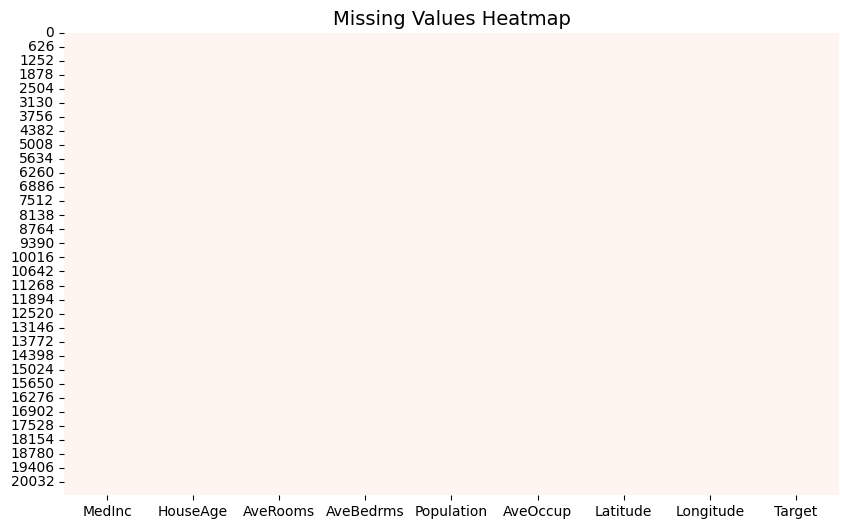

In [ ]:
# Basic info
df.shape
df.info()
df.describe()
# Null check
df.isnull().sum()
# Null check and missing values with heatmap
# Check for missing values visually
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='Reds')
plt.title('Missing Values Heatmap', fontsize=14)
plt.show()


When the heatmap is empty that means there is no empty value.
For a showcase I will introduce some random empty values in the next code chunck to show an example 
of heatmap usage to visualize null or missing values in a dataframe.

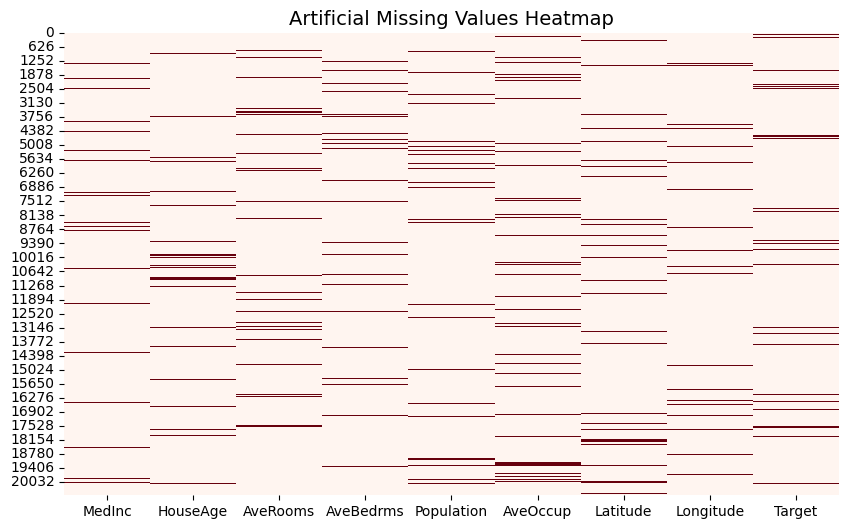

In [4]:
# Create a copy for demonstration
df_demo = df.copy()
# Randomly introduce NaNs into selected columns
np.random.seed(42)  # for reproducibility
missing_rate = 0.05  # 5% missing values

for col in ['MedInc', 'AveRooms', 'HouseAge', 'AveBedrms', 'Population', 'AveOccup','Latitude', 'Longitude', 'Target']:
    # Randomly choose indices to replace with NaN
    idx = np.random.choice(df_demo.index, size=int(missing_rate * len(df_demo)), replace=False)
    df_demo.loc[idx, col] = np.nan


plt.figure(figsize=(10, 6))
sns.heatmap(df_demo.isnull(), cbar=False, cmap='Reds')
plt.title('Artificial Missing Values Heatmap', fontsize=14)
plt.show()


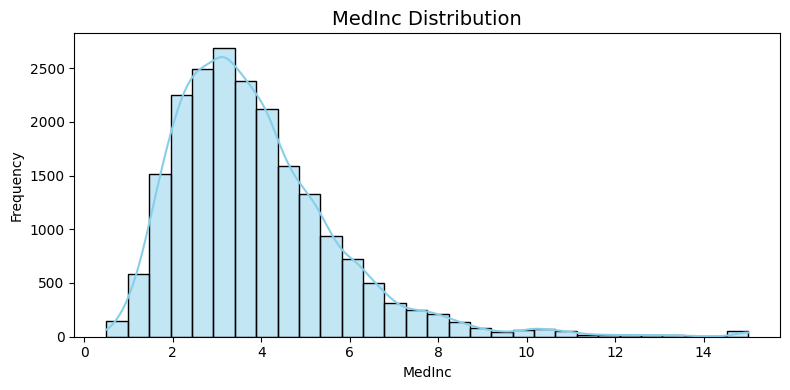

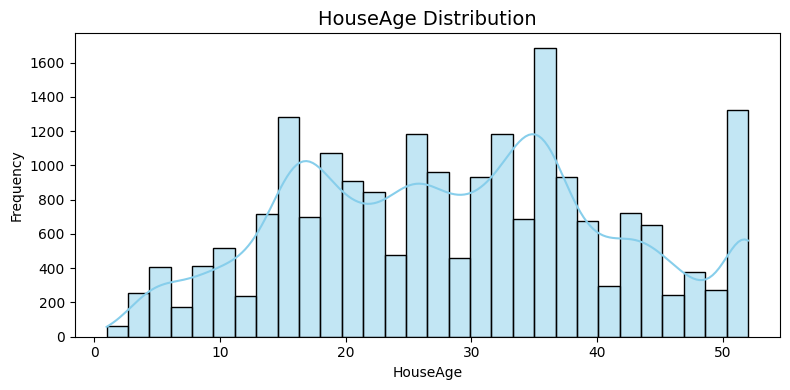

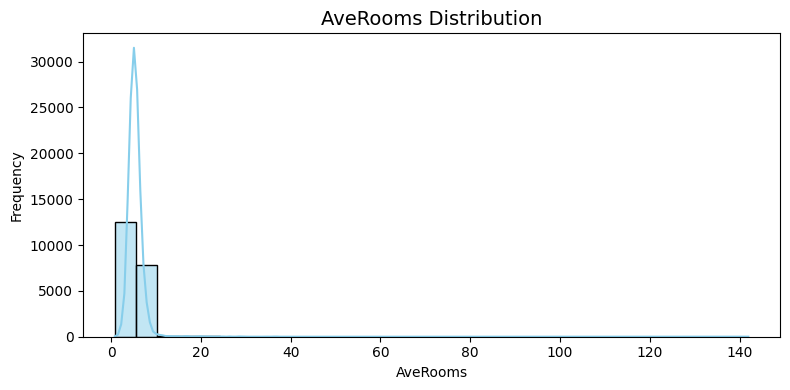

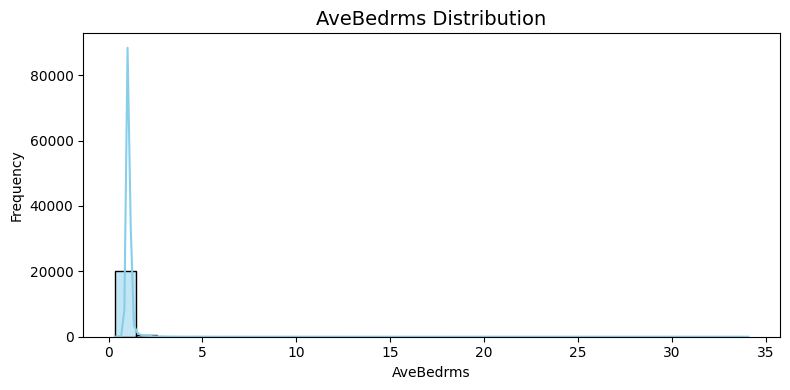

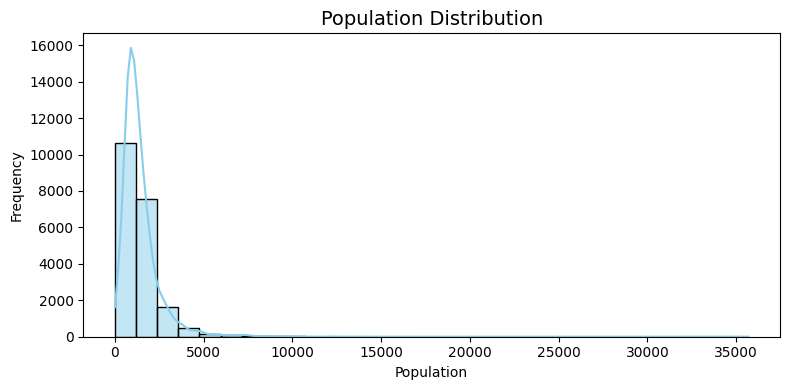

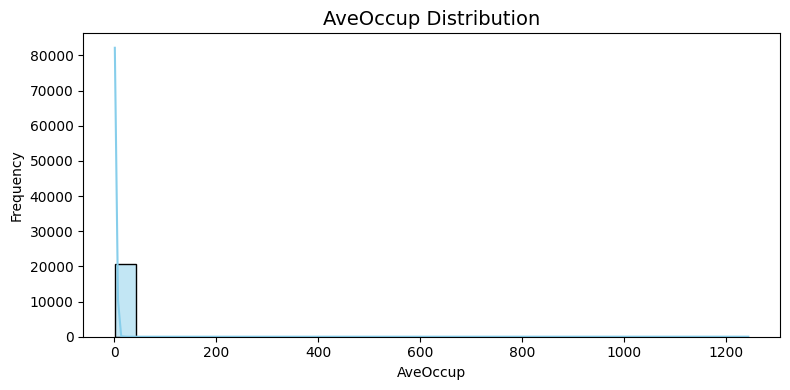

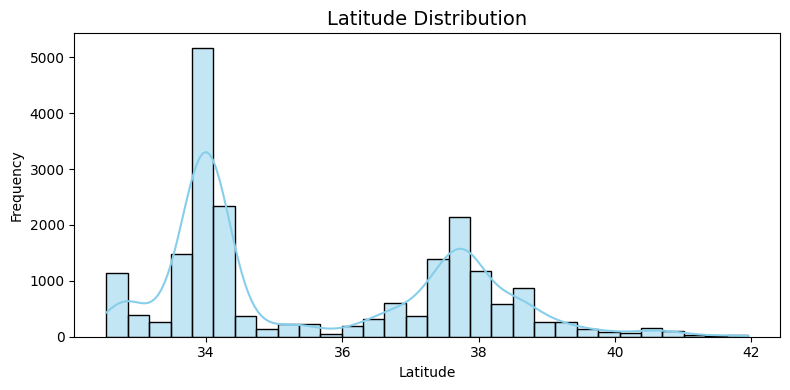

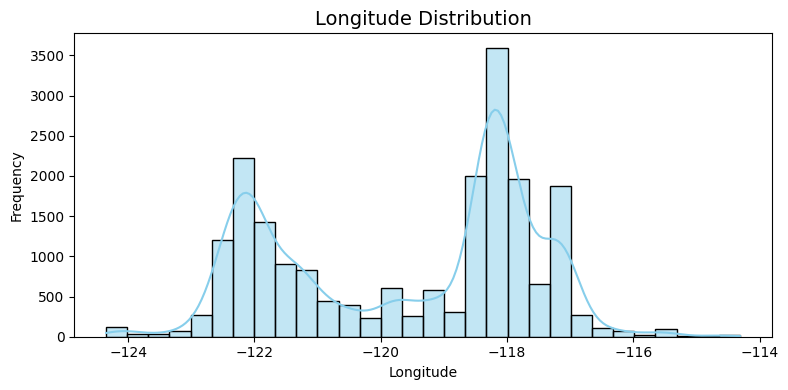

In [5]:
# Upgraded individual histograms
for col in df.columns[:-1]:  # exclude 'Target'
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, bins=30, kde=True, color='skyblue')
    plt.title(f'{col} Distribution', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


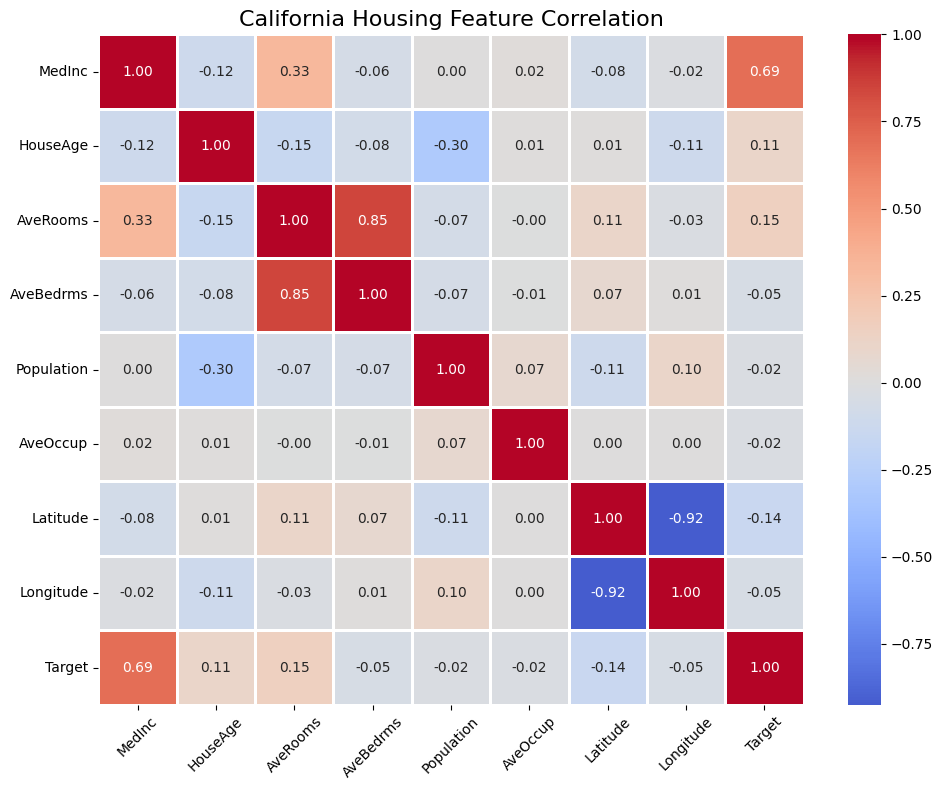

In [6]:
# Compute the full correlation matrix
corr_matrix = df.corr()

# Display with rounding for readability
corr_matrix.round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=1)
plt.title('California Housing Feature Correlation', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


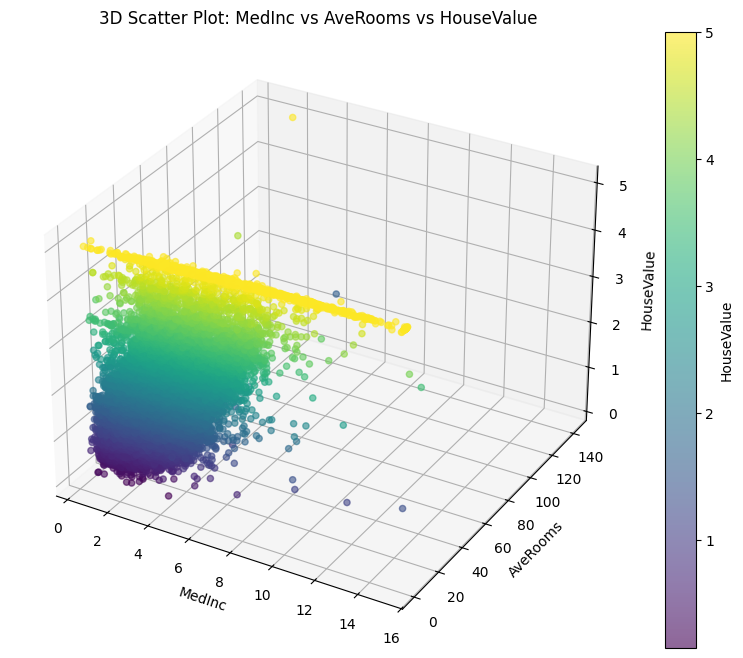

In [7]:
# Choose features for 3D plot
x = df['MedInc']                      # X-axis: Median Income
y = df['AveRooms']                   # Y-axis: Average Rooms (you can try others too)
z = df['Target']                     # Z-axis: House Value

# Create 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(x, y, z, c=z, cmap='viridis', alpha=0.6)
ax.set_xlabel('MedInc')
ax.set_ylabel('AveRooms')
ax.set_zlabel('HouseValue')
plt.colorbar(sc, label='HouseValue')

plt.title('3D Scatter Plot: MedInc vs AveRooms vs HouseValue')
plt.show()